In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [6]:
video_path = "./videos/RL1.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"fps={fps}, frames={frame_count}, size={width}x{height}, duration={frame_count/fps:.1f}s")

fps=60.000654583052075, frames=31043, size=3840x2160, duration=517.4s


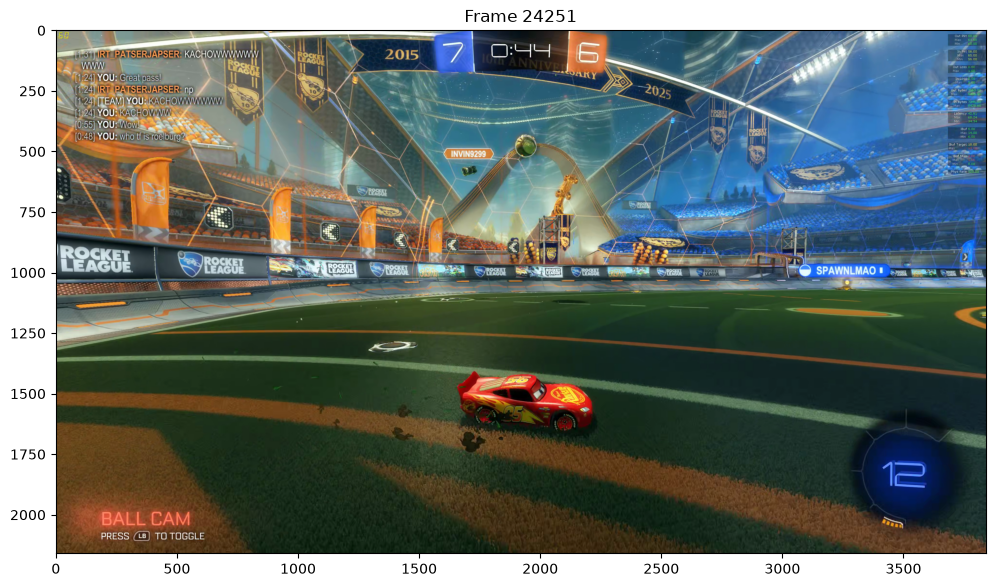

In [15]:
middle_frame_idx = frame_count // 2 + 8730

cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_idx)
ret, frame = cap.read()

if not ret:
    raise RuntimeError("Failed to read frame")

# OpenCV loads as BGR, matplotlib wants RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title(f"Frame {middle_frame_idx}")
plt.axis("on")  # keep axes on so you can read pixel coordinates
plt.show()

In [ ]:
cv2.imwrite("middle_frame.png", frame)
print("Saved middle_frame.png")

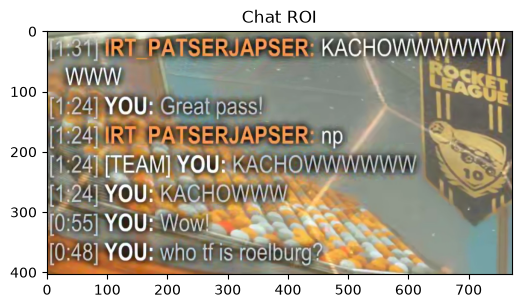

In [29]:
chat_roi = (int(width*0.02), int(height*0.033), int(width*0.221), int(height*0.22))      # placeholder

x1, y1, x2, y2 = chat_roi
chat_region = frame[y1:y2, x1:x2]

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(chat_region, cv2.COLOR_BGR2RGB))
plt.title("Chat ROI")
plt.show()

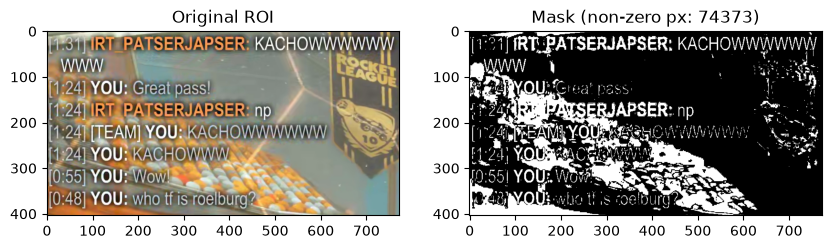

In [30]:
hsv = cv2.cvtColor(chat_region, cv2.COLOR_BGR2HSV)

# rough starting ranges — you'll want to tune these against real samples
lower_orange = np.array([5, 100, 100])
upper_orange = np.array([20, 255, 255])
lower_blue   = np.array([100, 100, 100])
upper_blue   = np.array([130, 255, 255])
lower_white  = np.array([0, 0, 200])
upper_white  = np.array([180, 30, 255])

mask = (
    cv2.inRange(hsv, lower_orange, upper_orange)
    | cv2.inRange(hsv, lower_blue, upper_blue)
    | cv2.inRange(hsv, lower_white, upper_white)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(chat_region, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original ROI")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Mask (non-zero px: {np.count_nonzero(mask)})")
plt.show()

Compared frames: [24246, 24247, 24248, 24249, 24250, 24251, 24252, 24253, 24254, 24255, 24256]
Stable pixels: 30194 / 311888


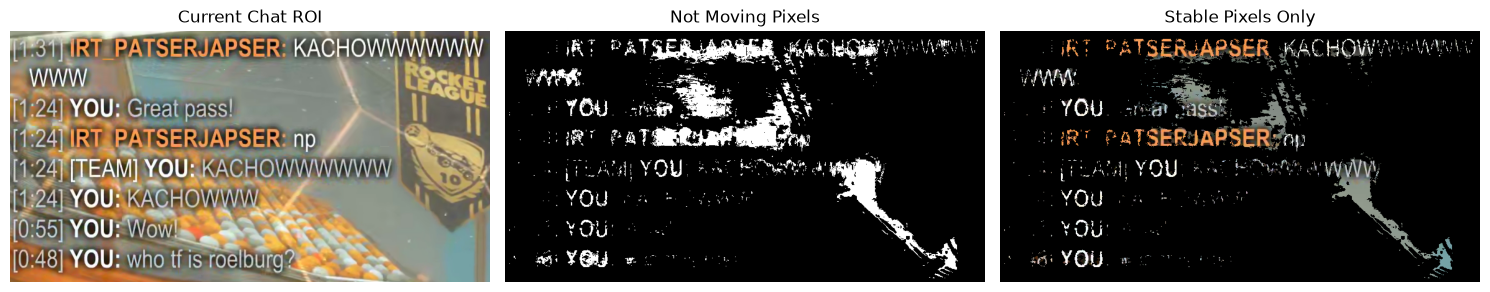

In [32]:
center_idx = middle_frame_idx
offsets = range(-5, 6)

roi_frames = []
used_indices = []

for off in offsets:
    idx = center_idx + off
    if idx < 0 or idx >= frame_count:
        continue

    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, fr = cap.read()
    if not ret:
        continue

    x1, y1, x2, y2 = chat_roi
    roi = fr[y1:y2, x1:x2]
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    roi_frames.append(roi_gray)
    used_indices.append(idx)

if len(roi_frames) < 2:
    raise RuntimeError("Not enough frames to compare")

stack = np.stack(roi_frames, axis=0).astype(np.int16)

# pixels with very small variation across the 7-frame window are treated as not moving
movement_range = stack.max(axis=0) - stack.min(axis=0)
stable_mask = movement_range <= 8

stable_pixels = np.zeros_like(chat_region)
stable_pixels[stable_mask] = chat_region[stable_mask]

print(f"Compared frames: {used_indices}")
print(f"Stable pixels: {np.count_nonzero(stable_mask)} / {stable_mask.size}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(chat_region, cv2.COLOR_BGR2RGB))
axes[0].set_title("Current Chat ROI")
axes[0].axis("off")

axes[1].imshow(stable_mask, cmap="gray")
axes[1].set_title("Not Moving Pixels")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(stable_pixels, cv2.COLOR_BGR2RGB))
axes[2].set_title("Stable Pixels Only")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Reconstructed chat text:
[24239] KSI PATSERUAPSER
[24239] [Kt 24\ WOU: Creat pees! K
[24239] RT ap
[24239] "
[24241] (29 VOU A
[24241] Ve ACO
[24241] Fg) OWE VAS
[24241] VOU uta Vis
[24243] PATEERUAPSER.
[24243] (28 VOU: Greet pasa &
[24243] ap NG
[24243] EDS
[24243] ano ts
[24245] (1 24] VOW: pass eS
[24245] (24) TEAM VOU: = NS
[24247] (02 PATSERUAPSER ap a
[24247] OUR SS. OS
[24247] (RAS) wna is
[24249] ap
[24249] BANG YOU: KACHONIUN SS
[24249] NSS
[24249] (08) VOU: wna tis NSS
[24251] () 24) VOU: Great pees
[24251] ap SN
[24251] (MEAN) VOU: Ss
[24251] HAR
[24251] DAR) VOU: wino SS |
[24253] [il PATSERUAPSER ap wit
[24253] VOM: NS
[24253] 22g] OWE NSE
[24255] op MM
[24255] Fg, Noe
[24257] HOW
[24257] PATSERUAPSER ap |
[24257] MEAN YOU: oS |
[24257] (2 Sy
[24259] (| 24) VOU:
[24259] () a
[24259] fi 24) (EAN VOW:
[24259] VOM: AS)
[24261] Wl
[24261] [i 24) (EAN Wow:
[24263] ||
[24263] (2a TEA VOU Ty
[24263] RON ane
[24263] (OSS) SS
[24263] who


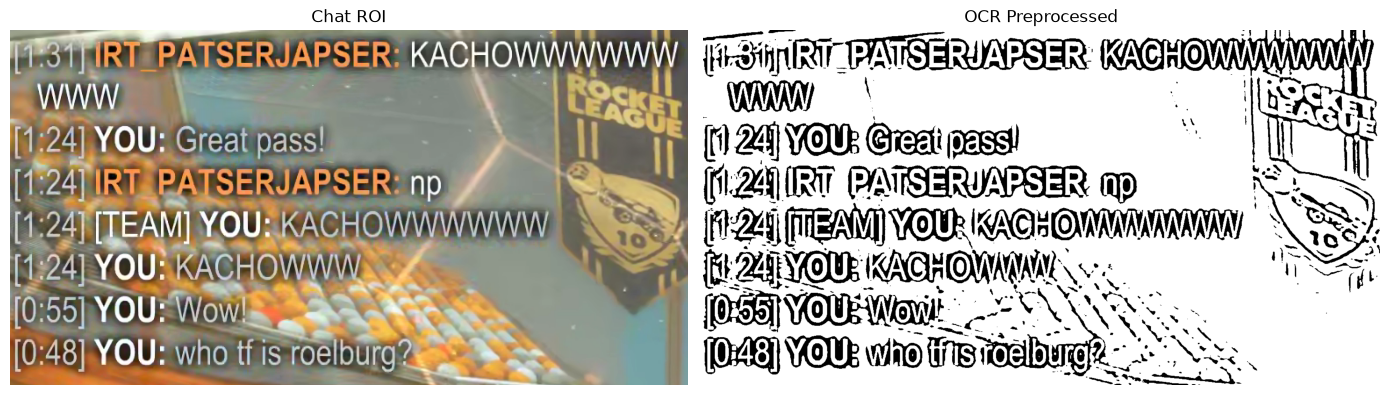

In [34]:
import pytesseract
import pandas as pd
from collections import defaultdict

def preprocess_for_ocr(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    th = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 11
    )
    return th

def ocr_lines(img_bgr):
    proc = preprocess_for_ocr(img_bgr)
    data = pytesseract.image_to_data(
        proc,
        output_type=pytesseract.Output.DATAFRAME,
        config="--psm 6"
    )
    data = data.dropna(subset=["text"])
    data = data[(data["conf"] > 30) & (data["text"].str.strip() != "")]

    lines = []
    for _, g in data.groupby(["block_num", "par_num", "line_num"]):
        g = g.sort_values("left")
        text = " ".join(g["text"].astype(str).tolist()).strip()
        if text:
            lines.append((int(g["top"].median()), text))
    return sorted(lines, key=lambda x: x[0]), proc, data

# sample a few frames around the current one
sample_offsets = range(-12, 13, 2)
all_lines = []

for off in sample_offsets:
    idx = center_idx + off
    if idx < 0 or idx >= frame_count:
        continue

    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, fr = cap.read()
    if not ret:
        continue

    x1, y1, x2, y2 = chat_roi
    crop = fr[y1:y2, x1:x2]
    lines, proc, data = ocr_lines(crop)

    for y, text in lines:
        all_lines.append((idx, y, text))

# de-duplicate consecutive near-identical lines
reconstructed = []
seen = set()
for idx, y, text in all_lines:
    key = text.lower()
    if key not in seen:
        seen.add(key)
        reconstructed.append((idx, y, text))

print("Reconstructed chat text:")
for idx, y, text in reconstructed:
    print(f"[{idx}] {text}")

# show OCR on the current frame crop
x1, y1, x2, y2 = chat_roi
crop = frame[y1:y2, x1:x2]
lines, proc, data = ocr_lines(crop)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
axes[0].set_title("Chat ROI")
axes[0].axis("off")

axes[1].imshow(proc, cmap="gray")
axes[1].set_title("OCR Preprocessed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Temporal contrast matte (no OCR)

This preserves the existing letters and team colors. A morphological **top-hat** isolates bright, narrow strokes in each frame. A temporal percentile keeps strokes that recur in the same location; connected-component filtering removes residual specks. Unlike the earlier motion mask, a pixel must also look like a bright stroke.

**Run cells 0–2 and 4 first**, or run the notebook normally. The experiment below does not need the OCR cells. It writes a transparent PNG and a portrait preview to `artifacts/`.

The two-second window works on this test frame because the messages stay fixed while the stadium moves. **Do not reuse this overlay for an entire clip:** messages appearing, scrolling, fading, or disappearing within the window can leave missing or stale letters. Shorten `window_seconds` near those events; static backgrounds and camera cuts also need separate handling. This is a sampled-frame prototype, not a finished video tracker.


In [ ]:
from pathlib import Path
from chat_overlay import sample_chat, extract_chat, composite_chat
from crop import crop_portrait

# Source-pixel tuning: the current 4K recording has letters about 36 px high.
# For a 1080p source start with text_height=18 and scale chat_roi accordingly.
samples, sample_indices = sample_chat(
    video_path, middle_frame_idx, chat_roi,
    window_seconds=2.0, sample_count=41,
)
chat_bgra, chat_debug = extract_chat(
    samples, text_height=36, percentile=35,
    threshold=32, edge_floor=16, opaque_contrast=71,
)
print(f"Used {len(samples)} samples from frames {sample_indices[0]}–{sample_indices[-1]}")
print("Higher threshold removes more noise; lower threshold keeps fainter strokes.")


Used 41 samples from frames 24191–24311
Higher threshold removes more noise; lower threshold keeps fainter strokes.


Saved artifacts/chat_overlay.png (BGRA transparency) and portrait_preview.png


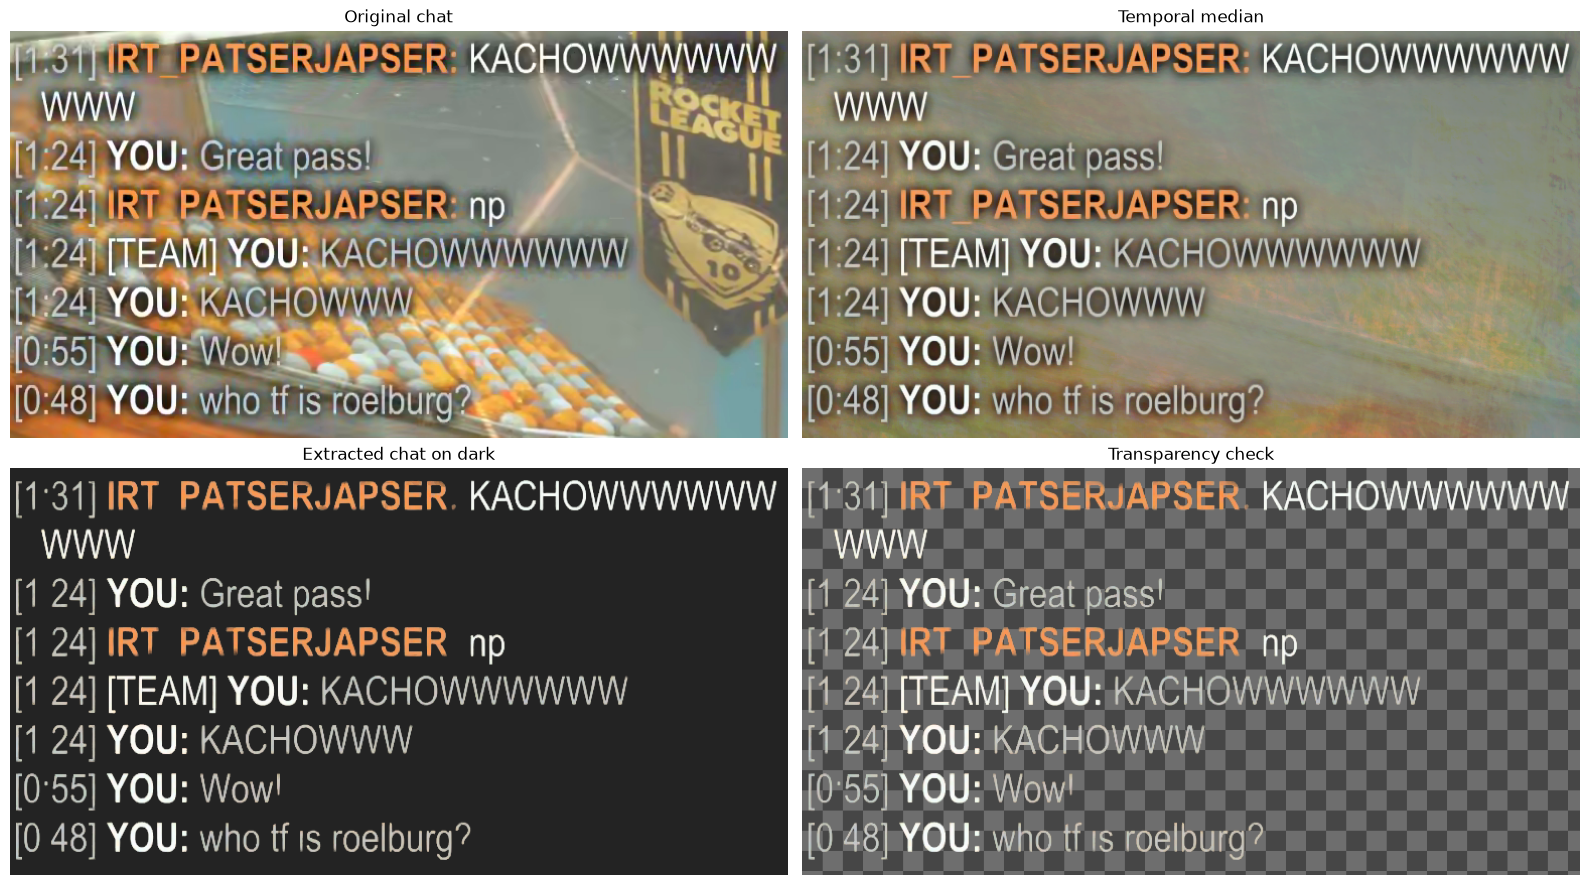

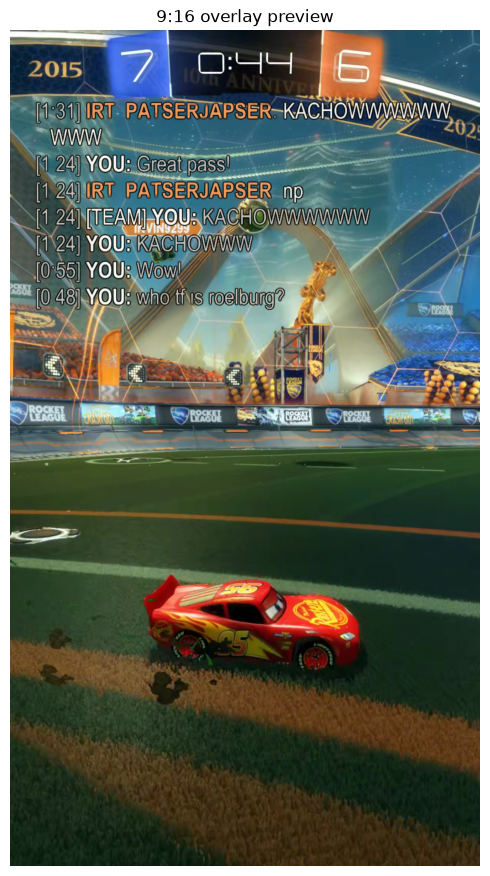

In [ ]:
# Contrast/checkerboard views make residual background and broken strokes visible.
h, w = chat_bgra.shape[:2]
yy, xx = np.indices((h, w))
checker_gray = np.where((xx // 20 + yy // 20) % 2, 70, 110).astype(np.uint8)
checker = np.repeat(checker_gray[:, :, None], 3, axis=2)
chat_on_checker = composite_chat(checker, chat_bgra)
chat_on_dark = composite_chat(np.full((h, w, 3), 35, np.uint8), chat_bgra)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, img, title in zip(axes.flat,
        [chat_region, chat_debug["median"], chat_on_dark, chat_on_checker],
        ["Original chat", "Temporal median", "Extracted chat on dark", "Transparency check"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
output_dir = Path("artifacts")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "chat_comparison.png", dpi=140, bbox_inches="tight")
plt.show()

# Composite at portrait resolution. A small black outline improves legibility.
portrait = crop_portrait(frame)
portrait_preview = composite_chat(portrait, chat_bgra,
                                  position=(54, 150), width=972, outline=2)
for filename, img in [("chat_overlay.png", chat_bgra),
                      ("portrait_preview.png", portrait_preview)]:
    if not cv2.imwrite(str(output_dir / filename), img):
        raise RuntimeError(f"Could not write {filename}")
plt.figure(figsize=(5, 9))
plt.imshow(cv2.cvtColor(portrait_preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("9:16 overlay preview")
plt.tight_layout()
plt.show()
print("Saved artifacts/chat_overlay.png (BGRA transparency) and portrait_preview.png")
